In [13]:
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
import random
import numpy as np
from scipy.spatial.distance import cosine
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.spatial.distance import cosine
from scipy.spatial.distance import cdist
from scipy.stats import ttest_rel, wilcoxon

#Read in the test data and keep only the songs with lyrics for the sentiment analysis/NLP lyric stuff. 
df1 = pd.read_csv("/Users/cheywakeland-hart/Desktop/lyrics_27_goemotions.csv")
df1 = df1[~(df1['lyrics']=="Instrumental")]
df1 = df1.drop(columns=["track_name", "artist_name"], errors="ignore")
df2 = pd.read_csv("/Users/cheywakeland-hart/Desktop/playlist_pred/data/playlist_subset/playlist_subset_4_test.csv")
df = pd.merge(df2, df1, on="track_uri", how="inner")
df = df[(df["found_tag"]=="1")]
df["track_id"] = df["track_name"] + " - " + df["artist_name"]
playlist_sequences = df.groupby("pid")["track_id"].apply(list).tolist()
emotion_cols = ["admiration","amusement","anger","annoyance","approval","caring","confusion", "curiosity", "desire", "disappointment", "disapproval","disgust", "embarrassment", "excitement", "fear","gratitude","grief","joy", "love","nervousness","optimism","pride","realization","relief","remorse","sadness","surprise","neutral"]
playlist_sequences = df.groupby("pid")["track_id"].apply(list).tolist()

In [29]:
results_df.to_csv("results_df.csv", index=False)
df.to_csv("final_test_df.csv", index=False)

PID 579641 → REG: 5, KM-W: 5, KM-E: 5
PID 612678 → REG: 5, KM-W: 5, KM-E: 5
PID 621544 → REG: 5, KM-W: 5, KM-E: 5
PID 992500 → REG: 5, KM-W: 5, KM-E: 5


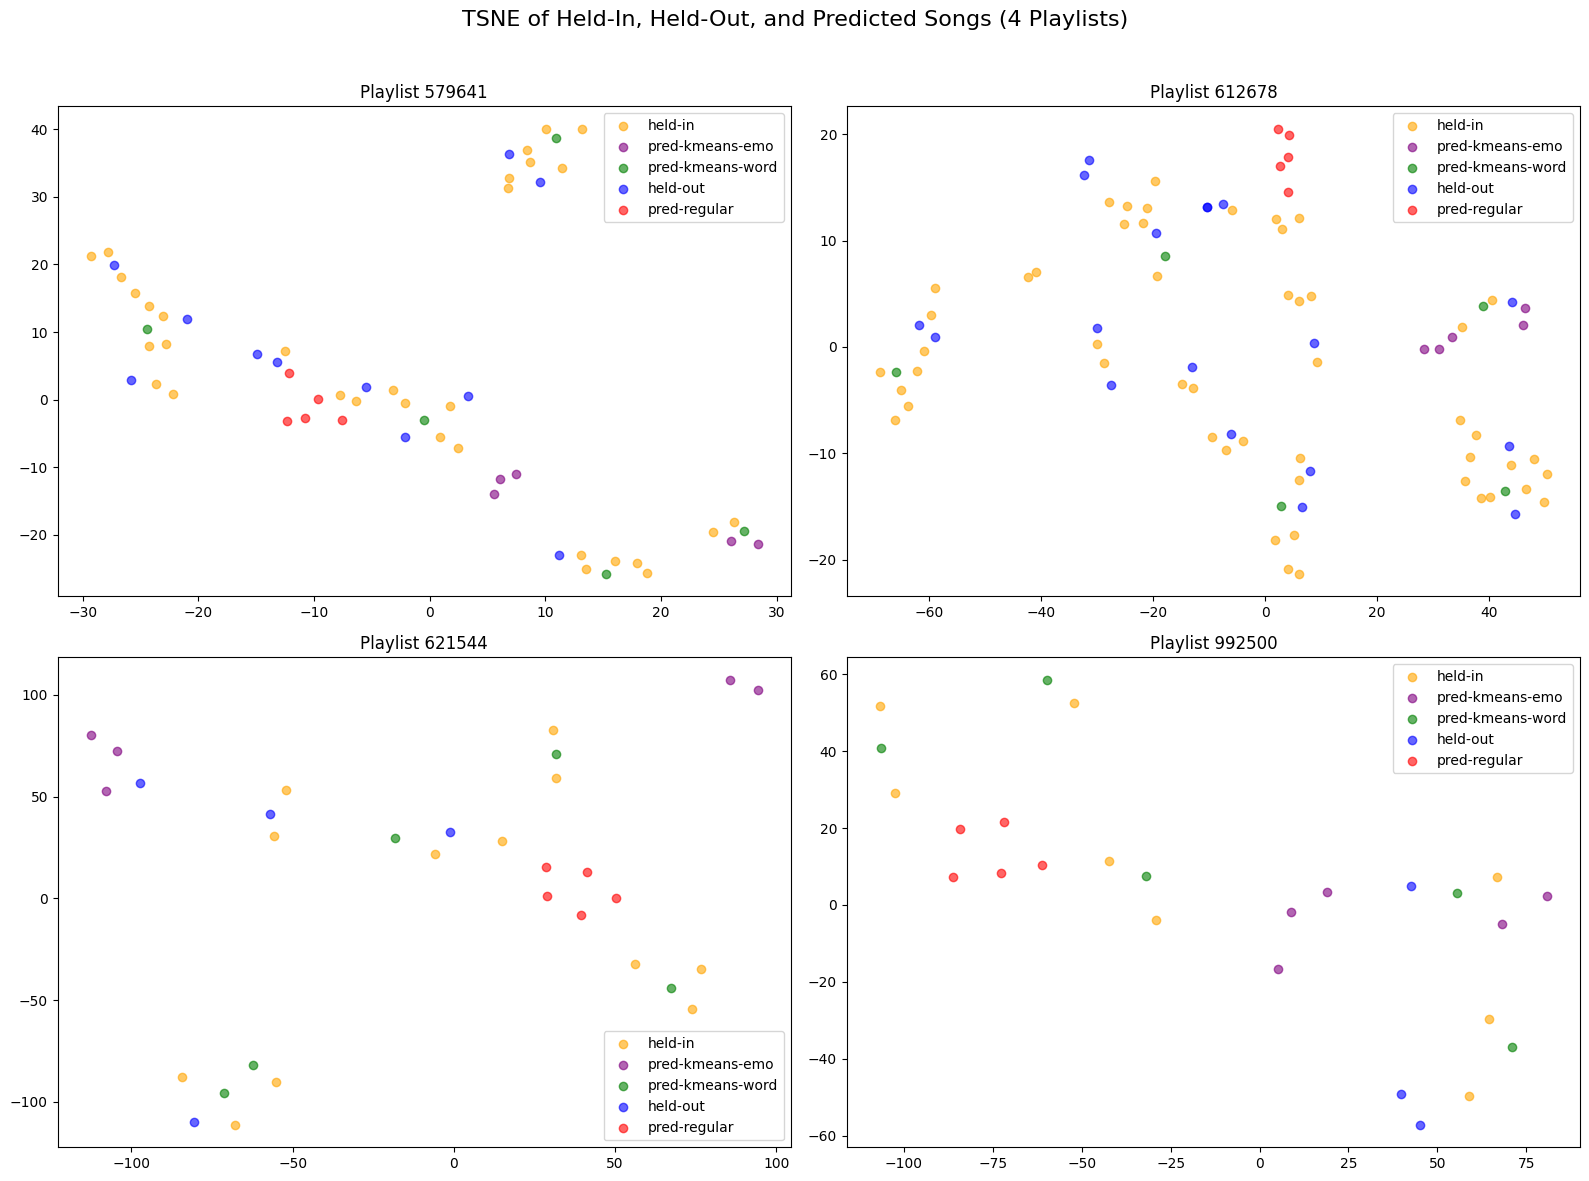

In [10]:
sample_pids = df["pid"].unique()
selected_pids = np.random.choice(sample_pids, 4, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, pid in enumerate(selected_pids):
    track_ids = df[df["pid"] == pid]["track_id"].tolist()
    if len(track_ids) < 6:
        continue

    # Split
    sample_size = int(len(track_ids) * 0.75)
    sampled = random.sample(track_ids, sample_size)
    held_out = [s for s in track_ids if s not in sampled]

    # Word vectors
    sampled_vecs = [model.wv[s] for s in sampled if s in model.wv]
    held_out_vecs = [model.wv[s] for s in held_out if s in model.wv]
    if len(sampled_vecs) < 3 or not held_out_vecs:
        continue

    # --- Regular mean predictions
    playlist_vec = np.mean(sampled_vecs, axis=0)
    sim_scores = [(s, 1 - cosine(playlist_vec, model.wv[s]))
                  for s in model.wv.index_to_key if s not in sampled]
    pred_regular = [model.wv[s] for s, _ in sorted(sim_scores, key=lambda x: x[1], reverse=True)[:5]]

    # --- KMeans Word2Vec
    kmeans_word = KMeans(n_clusters=5, random_state=42).fit(sampled_vecs)
    centers_word = kmeans_word.cluster_centers_
    def max_sim(vec, centers): return max(1 - cosine(vec, c) for c in centers)
    # Compute all sims
    # One top match per cluster center
    pred_kmeans_word = []
    used_songs = set()
    for center in centers_word:
        sims = [
            (s, 1 - cosine(model.wv[s], center))
            for s in model.wv.index_to_key
            if s not in sampled and s not in used_songs
        ]
        if sims:
            best_song, _ = max(sims, key=lambda x: x[1])
            pred_kmeans_word.append(model.wv[best_song])
            used_songs.add(best_song)


    #KMeans Emotion
    sampled_emo = [emotion_lookup[s] for s in sampled if s in emotion_lookup]
    if len(sampled_emo) < 3:
        continue
    kmeans_emo = KMeans(n_clusters=5, random_state=42).fit(sampled_emo)
    centers_emo = kmeans_emo.cluster_centers_
    def max_sim_emo(s):
        if s not in emotion_lookup:
            return -1
        return max(1 - cosine(emotion_lookup[s], c) for c in centers_emo)
    pred_kmeans_emo = [
        model.wv[s] for s in model.wv.index_to_key
        if s not in sampled and s in emotion_lookup and max_sim_emo(s) >= 0
    ][:5]

    # Diagnostics
    print(f"PID {pid} → REG: {len(pred_regular)}, KM-W: {len(pred_kmeans_word)}, KM-E: {len(pred_kmeans_emo)}")

    # Fallback dummy point if any are empty
    dummy = np.zeros(model.vector_size)
    if not pred_regular: pred_regular = [dummy]
    if not pred_kmeans_word: pred_kmeans_word = [dummy]
    if not pred_kmeans_emo: pred_kmeans_emo = [dummy]

    # Build vector-label pairs
    vectors = (
        [(v, "held-in") for v in sampled_vecs] +
        [(v, "held-out") for v in held_out_vecs] +
        [(v, "pred-regular") for v in pred_regular] +
        [(v, "pred-kmeans-word") for v in pred_kmeans_word] +
        [(v, "pred-kmeans-emo") for v in pred_kmeans_emo]
    )
    vecs, labels = zip(*vectors)
    vecs = np.array(vecs)

    # TSNE
    tsne_2d = TSNE(n_components=2, perplexity=5, random_state=42).fit_transform(vecs)

    # Plot
    ax = axes[i]
    palette = {
        "held-in": "orange",
        "held-out": "blue",
        "pred-regular": "red",
        "pred-kmeans-word": "green",
        "pred-kmeans-emo": "purple"
    }
    for label in set(labels):
        points = tsne_2d[np.array(labels) == label]
        ax.scatter(points[:, 0], points[:, 1], label=label, color=palette[label],alpha=.6)
    ax.set_title(f"Playlist {pid}")
    ax.legend()

plt.suptitle("TSNE of Held-In, Held-Out, and Predicted Songs (4 Playlists)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
    

In [14]:
#use word2vec to get the cooccurrence 
model = Word2Vec(sentences=playlist_sequences, vector_size=100, window=8, min_count=5, workers=4, sg=1)
all_song_ids = set(model.wv.index_to_key)

#read in the emotion data from the sentiment analysis
emotion_lookup = {
    row["track_id"]: row[emotion_cols].values
    for _, row in df.drop_duplicates("track_id").iterrows()
}

results = []
#for each playlist make sure its at least 6 songs in length and then split each playlist into 75% (used for prediction) and 25% (predicted by model)
for pid, group in tqdm(df.groupby("pid"), desc="Evaluating playlists"):
    track_ids = group["track_id"].tolist()
    if len(track_ids) < 6:
        continue

    sample_size = int(len(track_ids) * 0.75)
    sampled = random.sample(track_ids, sample_size)
    held_out = set(track_ids) - set(sampled)

    # Get playlist vectors for each type for kmeans there are 5 (1 for each cluster)
    vecs = [model.wv[s] for s in sampled if s in model.wv]
    emo_vecs = [emotion_lookup[s] for s in sampled if s in emotion_lookup]
    if len(vecs) < 5 or len(emo_vecs) < 5:
        continue

    playlist_vec = np.mean(vecs, axis=0)
    playlist_emo_vec = np.mean(emo_vecs, axis=0)


    kmeans_w2v = KMeans(n_clusters=5, random_state=42, n_init=10).fit(vecs)
    kmeans_emo = KMeans(n_clusters=5, random_state=42, n_init=10).fit(emo_vecs)
    centers_w2v = kmeans_w2v.cluster_centers_
    centers_emo = kmeans_emo.cluster_centers_
    centers_comb = [np.concatenate([w, e]) for w, e in zip(centers_w2v, centers_emo)]

    #get similarity scores for each of the models without clusters and pick top 5 closest songs to average vector
    word_scores = [(s, 1 - cosine(playlist_vec, model.wv[s]))
                   for s in all_song_ids - set(sampled) if s in model.wv]
    emo_scores = [(s, 1 - cosine(playlist_emo_vec, emotion_lookup[s]))
                  for s in all_song_ids - set(sampled) if s in emotion_lookup]
    comb_scores = [(s, 0.5 * (1 - cosine(playlist_vec, model.wv[s])) +
                    0.5 * (1 - cosine(playlist_emo_vec, emotion_lookup[s])))
                   for s in all_song_ids - set(sampled)
                   if s in model.wv and s in emotion_lookup]

    top5_word = [s for s, _ in sorted(word_scores, key=lambda x: x[1], reverse=True)[:5]]
    top5_emo = [s for s, _ in sorted(emo_scores, key=lambda x: x[1], reverse=True)[:5]]
    top5_comb = [s for s, _ in sorted(comb_scores, key=lambda x: x[1], reverse=True)[:5]]

    # 
    def top_per_center(centers, lookup, exclude):
        selected = []
        used = set()
        for center in centers:
            candidates = [(s, 1 - cosine(lookup[s], center))
                          for s in all_song_ids - exclude - used
                          if s in lookup]
            if candidates:
                best = max(candidates, key=lambda x: x[1])[0]
                selected.append(best)
                used.add(best)
        return selected

    top5_kword = top_per_center(centers_w2v, model.wv, set(sampled))
    top5_kemo = top_per_center(centers_emo, emotion_lookup, set(sampled))

    # For combined, average both embeddings
    combined_lookup = {
    s: np.concatenate([model.wv[s], emotion_lookup[s]])
    for s in all_song_ids - set(sampled)
    if s in model.wv and s in emotion_lookup
    }

    top5_kcomb = top_per_center(centers_comb, combined_lookup, set())

    #store hits for each playlist
    results.append({
        "pid": pid,
        "n_total": len(track_ids),
        "n_sampled": len(sampled),
        "n_held_out": len(held_out),
        "hits_word": sum(s in held_out for s in top5_word),
        "hits_emo": sum(s in held_out for s in top5_emo),
        "hits_comb": sum(s in held_out for s in top5_comb),
        "hits_kmeans_word": sum(s in held_out for s in top5_kword),
        "hits_kmeans_emo": sum(s in held_out for s in top5_kemo),
        "hits_kmeans_comb": sum(s in held_out for s in top5_kcomb)
    })

# Final results
results_df = pd.DataFrame(results)


Evaluating playlists:   5%|▉               | 211/3839 [04:09<1:14:13,  1.23s/it]/Users/cheywakeland-hart/mambaforge/envs/cleanenv/lib/python3.10/site-packages/sklearn/base.py:1363: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/cheywakeland-hart/mambaforge/envs/cleanenv/lib/python3.10/site-packages/sklearn/base.py:1363: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
Evaluating playlists:  36%|██████▏          | 1391/3839 [27:24<45:40,  1.12s/it]/Users/cheywakeland-hart/mambaforge/envs/cleanenv/lib/python3.10/site-packages/sklearn/base.py:1363: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
Evaluating play

In [15]:
results_df = pd.DataFrame(results)
n_with_hits1 = (results_df["hits_word"] >= 1).sum()
prop_with_hits1 = n_with_hits1 / len(results_df)
print(f"✅ Co-occurrance only Playlists with at least 1 correct song in top 5: {n_with_hits1}/{len(results_df)} ({prop_with_hits1:.2%})")
results_df = pd.DataFrame(results)
n_with_hits2 = (results_df["hits_emo"] >= 1).sum()
prop_with_hits2 = n_with_hits2 / len(results_df)
print(f"✅ Emotion only Playlists with at least 1 correct song in top 5: {n_with_hits2}/{len(results_df)} ({prop_with_hits2:.2%})")
n_with_hits3 = (results_df["hits_comb"] >= 1).sum()
prop_with_hits3 = n_with_hits3 / len(results_df)
print(f"✅ Combined Playlists with at least 1 correct song in top 5: {n_with_hits3}/{len(results_df)} ({prop_with_hits3:.2%})")
n_with_hits4 = (results_df["hits_kmeans_word"] >= 1).sum()
prop_with_hits4 = n_with_hits4 / len(results_df)
print(f"✅ Co-occurrance kmeans only Playlists with at least 1 correct song in top 5: {n_with_hits4}/{len(results_df)} ({prop_with_hits4:.2%})")
results_df = pd.DataFrame(results)
n_with_hits5 = (results_df["hits_kmeans_emo"] >= 1).sum()
prop_with_hits5 = n_with_hits5 / len(results_df)
print(f"✅ Emotion kmeans only Playlists with at least 1 correct song in top 5: {n_with_hits5}/{len(results_df)} ({prop_with_hits5:.2%})")
n_with_hits6 = (results_df["hits_kmeans_comb"] >= 1).sum()
prop_with_hits6 = n_with_hits6 / len(results_df)
print(f"✅ Combined kmeans Playlists with at least 1 correct song in top 5: {n_with_hits6}/{len(results_df)} ({prop_with_hits6:.2%})")


✅ Co-occurrance only Playlists with at least 1 correct song in top 5: 467/3310 (14.11%)
✅ Emotion only Playlists with at least 1 correct song in top 5: 41/3310 (1.24%)
✅ Combined Playlists with at least 1 correct song in top 5: 232/3310 (7.01%)
✅ Co-occurrance kmeans only Playlists with at least 1 correct song in top 5: 668/3310 (20.18%)
✅ Emotion kmeans only Playlists with at least 1 correct song in top 5: 52/3310 (1.57%)
✅ Combined kmeans Playlists with at least 1 correct song in top 5: 446/3310 (13.47%)


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.spatial.distance import cosine
import numpy as np
import random

# You must already have df, model (Word2Vec), and emotion_lookup defined
sample_pids = df["pid"].unique()
selected_pids = np.random.choice(sample_pids, 4, replace=False)

label_map = {
    "held-in": "Playlist Songs",
    "held-out": "Held Out",
    "pred-regular": "Playlist Avg. Predictions",
    "pred-kmeans-word": "Co-Occur. Cluster Predictions",
    "pred-kmeans-emo": "Emotion Cluster Predictions"
}

color_map = {
    "Playlist Songs": "#3B9C9C",
    "Held Out": "#3B9C9C",
    "Playlist Avg. Predictions": "#D48E91",
    "Co-Occur. Cluster Predictions": "#89A1B1",
    "Emotion Cluster Predictions": "#9BBF9B"
}

vectors_dict = {}

for pid in selected_pids:
    track_ids = df[df["pid"] == pid]["track_id"].tolist()
    if len(track_ids) < 6:
        continue

    # Split into 75% sampled / 25% held out
    sample_size = int(len(track_ids) * 0.75)
    sampled = random.sample(track_ids, sample_size)
    held_out = [s for s in track_ids if s not in sampled]

    sampled_vecs = [model.wv[s] for s in sampled if s in model.wv]
    sampled_emo = [emotion_lookup[s] for s in sampled if s in emotion_lookup]
    held_out_vecs = [model.wv[s] for s in held_out if s in model.wv]

    if len(sampled_vecs) < 5 or len(sampled_emo) < 5 or not held_out_vecs:
        continue

    # Regular average playlist vector predictions
    playlist_vec = np.mean(sampled_vecs, axis=0)
    sim_scores = [(s, 1 - cosine(playlist_vec, model.wv[s]))
                  for s in model.wv.index_to_key if s not in sampled]
    pred_regular = [model.wv[s] for s, _ in sorted(sim_scores, key=lambda x: x[1], reverse=True)[:5]]

    # KMeans (5 clusters)
    kmeans_word = KMeans(n_clusters=5, random_state=42).fit(sampled_vecs)
    centers_word = kmeans_word.cluster_centers_

    kmeans_emo = KMeans(n_clusters=5, random_state=42).fit(sampled_emo)
    centers_emo = kmeans_emo.cluster_centers_

    def max_sim(vec, centers):
        return max(1 - cosine(vec, center) for center in centers)

    pred_kmeans_word = [model.wv[s] for s, _ in sorted([
        (s, max_sim(model.wv[s], centers_word))
        for s in model.wv.index_to_key if s not in sampled
    ], key=lambda x: x[1], reverse=True)[:5]]

    pred_kmeans_emo = [model.wv[s] for s in model.wv.index_to_key
        if s not in sampled and s in emotion_lookup
    ]
    pred_kmeans_emo = [model.wv[s] for s, _ in sorted([
        (s, max_sim(emotion_lookup[s], centers_emo))
        for s in df["track_id"].unique() if s in emotion_lookup and s not in sampled
    ], key=lambda x: x[1], reverse=True)[:5]]

    # Save vectors to dict
    vectors_dict[pid] = (
        [(v, "held-in") for v in sampled_vecs] +
        [(v, "held-out") for v in held_out_vecs] +
        [(v, "pred-regular") for v in pred_regular] +
        [(v, "pred-kmeans-word") for v in pred_kmeans_word] +
        [(v, "pred-kmeans-emo") for v in pred_kmeans_emo]
    )

# ------------------------------
# TSNE PLOTTING FUNCTION
# ------------------------------
def plot_tsne_subset(vectors_dict, selected_pids, title, exclude_labels=[]):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, pid in enumerate(selected_pids):
        if pid not in vectors_dict:
            continue

        vectors = vectors_dict[pid]
        filtered = [(v, label_map[t]) for v, t in vectors if label_map[t] not in exclude_labels]

        if not filtered:
            continue

        vecs, labels = zip(*filtered)
        vecs = np.array(vecs)
        tsne_coords = TSNE(n_components=2, perplexity=5, random_state=42).fit_transform(vecs)

        ax = axes[i]
        for label in set(labels):
            points = tsne_coords[np.array(labels) == label]
            ax.scatter(points[:, 0], points[:, 1], label=label, color=color_map[label])
        ax.set_title(f"Playlist {pid}")
        ax.legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# ------------------------------
# EXAMPLE USAGE
# ------------------------------

# 1. Only Playlist Songs and Held Out
plot_tsne_subset(vectors_dict, selected_pids, "Playlist Songs and Held Out Only",
                 exclude_labels=["Playlist Avg. Predictions", "Co-Occur. Cluster Predictions", "Emotion Cluster Predictions"])

# 2. Playlist Songs, Held Out, and Avg. Predictions
plot_tsne_subset(vectors_dict, selected_pids, "Playlist Songs, Held Out, and Avg. Predictions",
                 exclude_labels=["Co-Occur. Cluster Predictions", "Emotion Cluster Predictions"])

# 3. All Except Co-Occur. Cluster Predictions
plot_tsne_subset(vectors_dict, selected_pids, "All Except Co-Occur. Cluster Predictions",
                 exclude_labels=["Co-Occur. Cluster Predictions"])



KeyError: "Key 'What's My Name - China Anne McClain' not present"

In [26]:


results = []

for pid in vectors_dict:
    data = vectors_dict[pid]
    heldin = np.array([v for v, label in data if label == "held-in"])
    if len(heldin) == 0:
        continue

    def mean_dist_to(pred_label):
        preds = np.array([v for v, label in data if label == pred_label])
        if len(preds) == 0:
            return np.nan
        dists = cdist(heldin, preds, metric='euclidean')
        return dists.mean()

    results.append({
        "pid": pid,
        "25% Held Out": mean_dist_to("held-out"),
        "Avg. Co-Occurrence": mean_dist_to("pred-regular"),
        "Cluster Co-Occurrence": mean_dist_to("pred-kmeans-word"),
        "Cluster Emotion": mean_dist_to("pred-kmeans-emo")
    })

dist_df = pd.DataFrame(results)

# --- Visualize ---
melted = dist_df.melt(id_vars="pid", var_name="prediction_type", value_name="mean_distance")
plt.figure(figsize=(10,6))
sns.boxplot(data=melted, x="prediction_type", y="mean_distance")
plt.title("Mean Distance to Playlist Songs by Prediction Type")
plt.ylabel("Average Euclidean Distance")
plt.xlabel("Prediction Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Paired comparisons ---
print("KMeans W2V vs Regular Mean:", ttest_rel(dist_df["pred_kmeans_word"], dist_df["pred_regular"], nan_policy='omit'))
print("KMeans W2V vs Heldout:", ttest_rel(dist_df["pred_kmeans_word"], dist_df["heldout"], nan_policy='omit'))


KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['pid']"

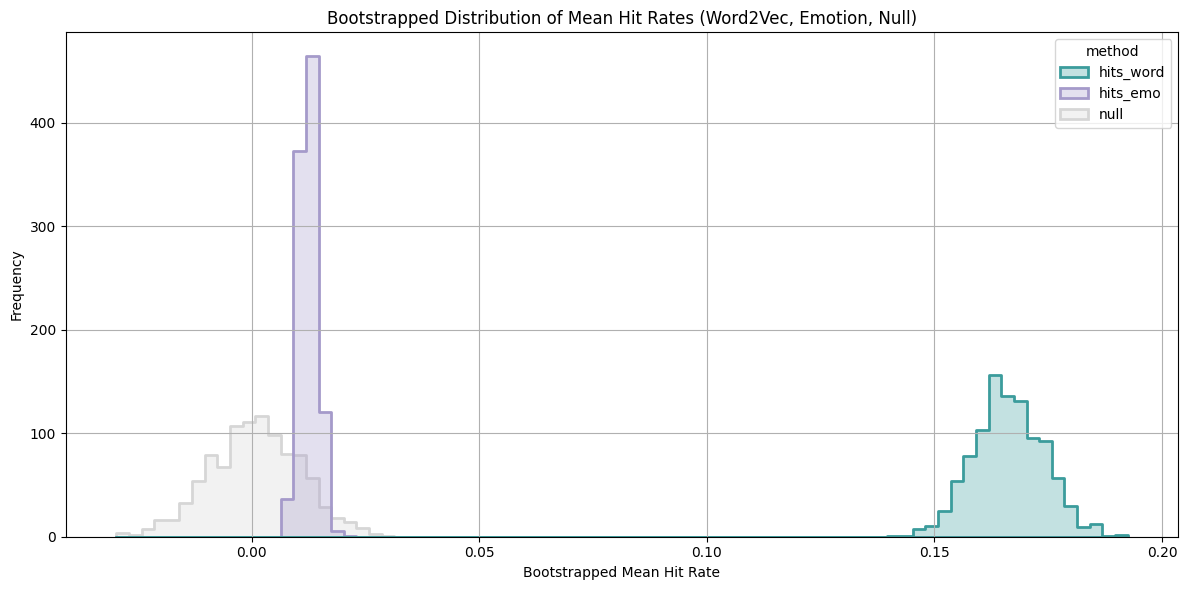

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming `results_df` is already defined in your environment
# And includes: hits_word, hits_emo

n_boot = 1000
boot_data = []

# Bootstrap distributions
for method in ["hits_word", "hits_emo"]:
    values = results_df[method].values
    for _ in range(n_boot):
        sample = np.random.choice(values, size=len(values), replace=True)
        boot_data.append({
            "method": method,
            "mean_hit_rate": np.mean(sample)
        })

# Null distribution centered at 0
for val in np.random.normal(loc=0.0, scale=0.01, size=n_boot):
    boot_data.append({
        "method": "null",
        "mean_hit_rate": val
    })

boot_df = pd.DataFrame(boot_data)

# Plotting
plt.figure(figsize=(12, 6))
palette = {
    "hits_word": "#3B9C9C",
    "hits_emo": "#A59ACA",
    "null": "#D6D6D6"  # light neutral gray for null
}

sns.histplot(
    data=boot_df,
    x="mean_hit_rate",
    hue="method",
    bins=80,  # More bins = smaller bars
    stat="count",
    common_norm=False,
    element="step",
    fill=True,
    palette=palette,
    alpha=0.3,
    linewidth=2
)

plt.title("Bootstrapped Distribution of Mean Hit Rates (Word2Vec, Emotion, Null)")
plt.xlabel("Bootstrapped Mean Hit Rate")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


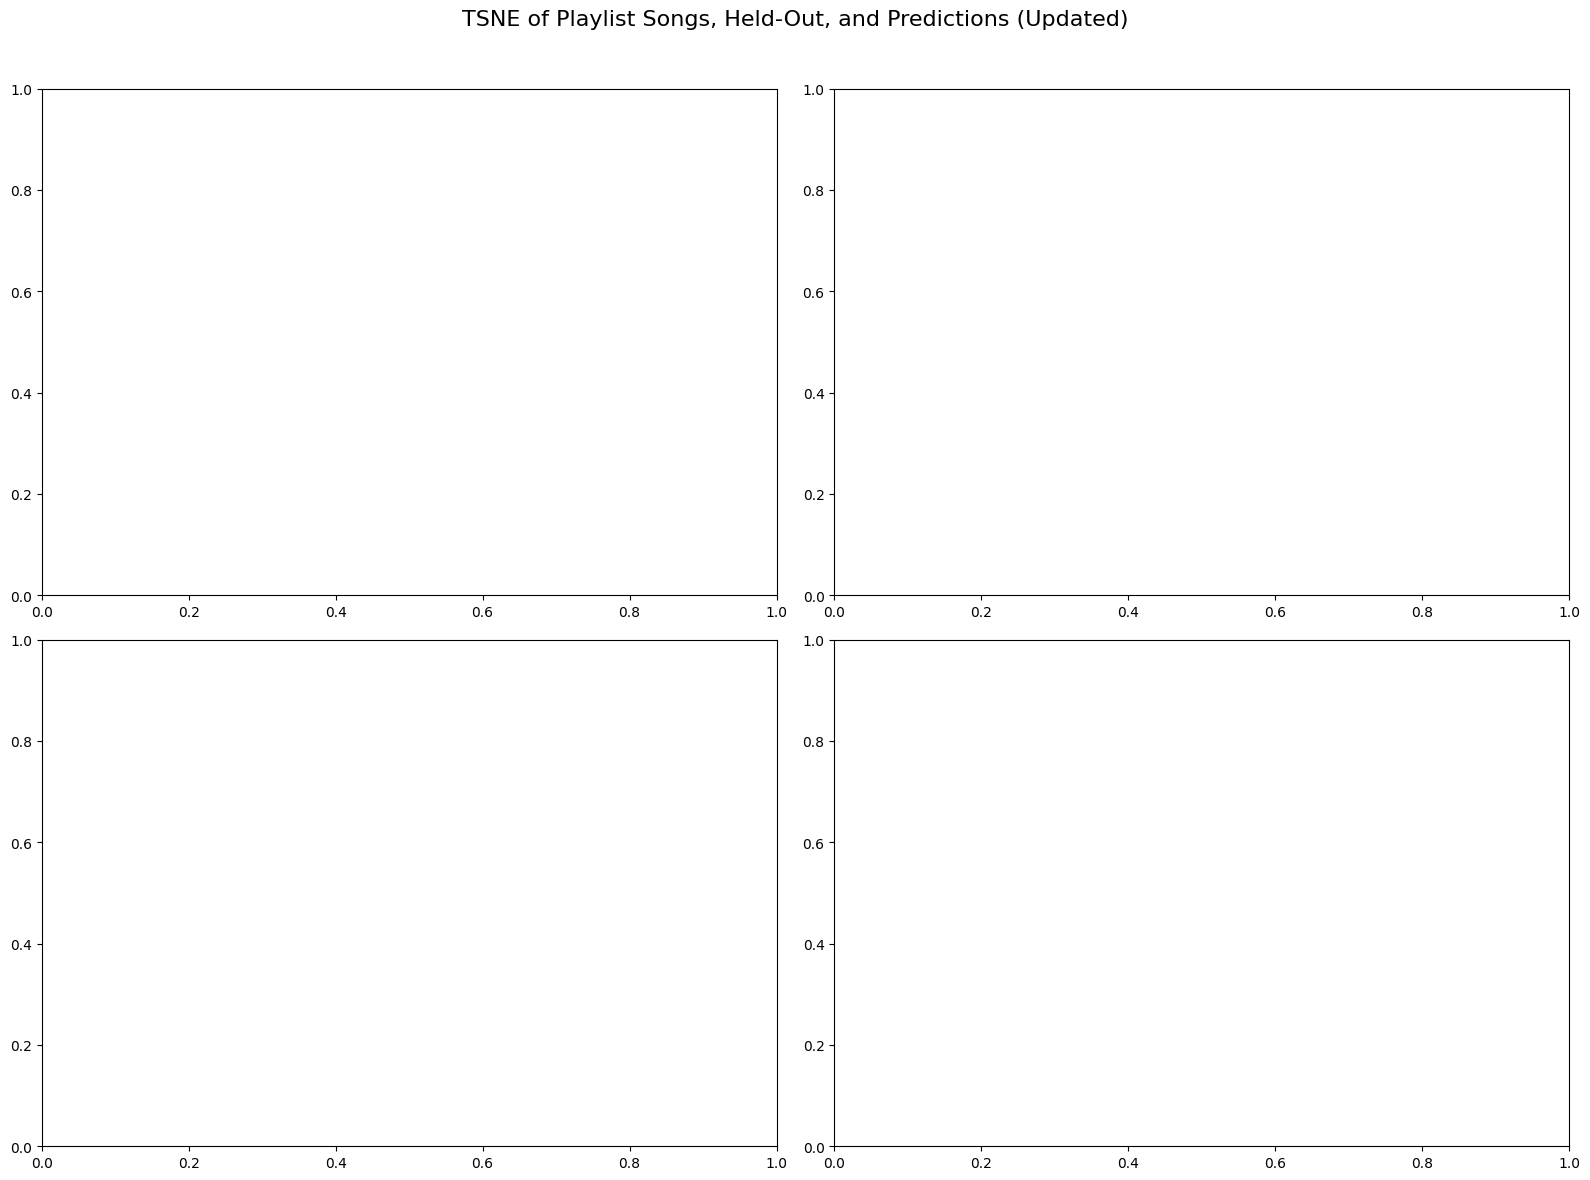

In [30]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np

# Simulate or load your `vectors_dict` here
# vectors_dict = {pid: [(vector, label), ...], ...}

label_map = {
    "held-in": "Playlist Songs",
    "held-out": "Held Out",
    "pred-regular": "Playlist Avg. Predictions",
    "pred-kmeans-word": "Co-Occur. Cluster Predictions",
    "pred-kmeans-emo": "Emotion Cluster Predictions"
}

color_map = {
    "Playlist Songs": "#3B9C9C",
    "Held Out": "#2F4858",
    "Playlist Avg. Predictions": "#D48E91",
    "Co-Occur. Cluster Predictions": "#89A1B1",
    "Emotion Cluster Predictions": "#9BBF9B"
}

sample_pids = [579641, 612678, 621544, 992500]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, pid in enumerate(sample_pids):
    if pid not in vectors_dict:
        continue

    vectors = vectors_dict[pid]
    vecs, raw_labels = zip(*vectors)
    vecs = np.array(vecs)
    labels = [label_map[l] for l in raw_labels]

    # Dimensionality reduction to speed up TSNE
    vecs_reduced = PCA(n_components=30).fit_transform(vecs)
    tsne_coords = TSNE(n_components=2, perplexity=5, method='exact', random_state=42).fit_transform(vecs_reduced)

    ax = axes[i]
    for label in set(labels):
        points = tsne_coords[np.array(labels) == label]
        ax.scatter(points[:, 0], points[:, 1], label=label, color=color_map[label])
    ax.set_title(f"Playlist {pid}")
    ax.legend()

plt.suptitle("TSNE of Playlist Songs, Held-Out, and Predictions (Updated)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [31]:
for pid in sample_pids:
    print(f"{pid} in vectors_dict? →", pid in vectors_dict)


579641 in vectors_dict? → False
612678 in vectors_dict? → False
621544 in vectors_dict? → False
992500 in vectors_dict? → False


In [32]:
print(list(vectors_dict.keys())[:10])


[962564]
